# Testing GSDR from TheWell with PDEformer-2
GSDR TheWell is not part of PDEFoundry, which PDEformer is pretrained on.

# Load model

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mindspore import context
from src import load_config, get_model, PDENodesCollector, sample_grf
from src.inference import infer_plot_2d, x_fenc, y_fenc, interp_fenc, inference_cartesian, inference_pde

# basic setting
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")
config = load_config("configs/inference/model-M.yaml")
model = get_model(config)

[WARNING] ME(22584:8304385664,MainProcess):2026-05-22-02:02:26.696.000 [mindspore/context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


# Generating DAG for GSDR
Referenced from PDEformer's notebooks.

From dataset_overview.md:
to_fields/A and B are the 'data'.

Since GSDR TheWell has t $\in$[0,10000], I attempt to subsample every 100th step such that I have t $\in$[0,1].

The feed/kill rate are also saved as variables, since they will be used in the DAG generation later.

In [23]:
import h5py
import numpy as np

pdb_gsdr = '/Volumes/T7/TheWell/datasets/gray_scott_reaction_diffusion/data/test/gray_scott_reaction_diffusion_bubbles_F_0.098_k_0.057.hdf5'

with h5py.File(pdb_gsdr, 'r') as f:
    print(f.keys())
    print()

    print("BOUNDARY CONDITIONS")
    print(f['boundary_conditions'].keys())
    print(f['boundary_conditions']['x_periodic']['mask'])
    print(f['boundary_conditions']['y_periodic']['mask'])
    print()

    print("DIMENSIONS")
    print(f['dimensions'].keys())
    dimensions = f['dimensions']
    for key in dimensions:
        print(dimensions[key])
    print()

    print(f['scalars'].keys())
    print(f['scalars']['F'][()])
    print(f['scalars']['k'][()])
    print()

    print(f['t0_fields'].keys())
    print('TO FIELDS')
    print(f['t0_fields']['A'])
    # print(f['t1_fields']) #empty
    # print(f['t2_fields']) #empty

    x_coord = f['dimensions/x'][:]
    y_coord = f['dimensions/y'][:]
    t_coord = f['dimensions/time'][:]
    # snap_t = t_coord[::100]
    snap_t = t_coord[0::10] # Gets exactly 101 frames, dt=10*10=100

    xx, yy = np.meshgrid(x_coord, y_coord, indexing="ij")
    x_part = x_coord[None, :, None]
    y_part = y_coord[None, None, :]
    # t_part = snap_t[:, None, None]
    normalized_t = snap_t / 10000
    t_part = normalized_t[:, None, None]
    coord = np.stack(np.broadcast_arrays(t_part, x_part, y_part,0), axis=-1)

    print(coord.shape)

    init_A = f['t0_fields']['A'][0, 0, :, :]
    reference_A = f['t0_fields']['A'][:]
    reference_B = f['t0_fields']['B'][:]

    sliced_ref_A = f['t0_fields']['A'][0, ::100, :, :]
    sliced_ref_B = f['t0_fields']['B'][0, ::100, :, :]
    reference = np.stack((sliced_ref_A, sliced_ref_B), axis=-1)



<KeysViewHDF5 ['boundary_conditions', 'dimensions', 'scalars', 't0_fields', 't1_fields', 't2_fields']>

BOUNDARY CONDITIONS
<KeysViewHDF5 ['x_periodic', 'y_periodic']>
<HDF5 dataset "mask": shape (128,), type "|b1">
<HDF5 dataset "mask": shape (128,), type "|b1">

DIMENSIONS
<KeysViewHDF5 ['time', 'x', 'y']>
<HDF5 dataset "time": shape (1001,), type "<f4">
<HDF5 dataset "x": shape (128,), type "<f4">
<HDF5 dataset "y": shape (128,), type "<f4">

<KeysViewHDF5 ['F', 'k']>
0.098
0.057

<KeysViewHDF5 ['A', 'B']>
TO FIELDS
<HDF5 dataset "A": shape (20, 1001, 128, 128), type "<f4">
(101, 128, 128, 4)


IC:Random Cluster of Gaussians, sim0

Note: GSDR TheWell has multiple simulations, however, there are 2 different initial conditions (Random Cluster of Gaussians, Random Fourier series). The fastest way to differentiate between the 2 ICs is to take a sim and plot out at t=0.

This example below uses sim0, which has random cluster of Gaussians as its IC. A plot of a simulation with random fourier series as its IC is shown below as well, for visual comparison.

When setting the BC, it is periodic by default. Since GSDR's BC is also periodic, there is no need to do anything.

The DAG below is generated based on the IC of GSDR, which is taken to be t=0 for variables A and B.

The respective coefficients are also used here.

The equations are taken from TheWell's paper.

[('uf0', 'uf'), ('uf1', 'uf'), ('ic2', 'ic', 'uf0'), ('ic3', 'ic', 'uf1'), ('coef4', 'coef'), ('coef5', 'coef'), ('coef6', 'coef'), ('coef7', 'coef'), ('dt8', 'dt', 'uf0'), ('neg9', 'neg', 'coef6'), ('dx10', 'dx', 'uf0'), ('dx11', 'dx', 'dx10'), ('mul12', 'mul', 'neg9', 'dx11'), ('neg13', 'neg', 'coef6'), ('dy14', 'dy', 'uf0'), ('dy15', 'dy', 'dy14'), ('mul16', 'mul', 'neg13', 'dy15'), ('square17', 'square', 'uf1'), ('mul18', 'mul', 'uf0', 'square17'), ('neg19', 'neg', 'coef4'), ('neg20', 'neg', 'uf0'), ('coef21', 'coef'), ('add22', 'add', 'coef21', 'neg20'), ('mul23', 'mul', 'neg19', 'add22'), ('add24', 'add', 'dt8', 'mul12', 'mul16', 'mul18', 'mul23'), ('eq025', 'eq0', 'add24'), ('dt26', 'dt', 'uf1'), ('neg27', 'neg', 'coef7'), ('dx28', 'dx', 'uf1'), ('dx29', 'dx', 'dx28'), ('mul30', 'mul', 'neg27', 'dx29'), ('neg31', 'neg', 'coef7'), ('dy32', 'dy', 'uf1'), ('dy33', 'dy', 'dy32'), ('mul34', 'mul', 'neg31', 'dy33'), ('neg35', 'neg', 'uf0'), ('mul36', 'mul', 'neg35', 'square17'), ('add

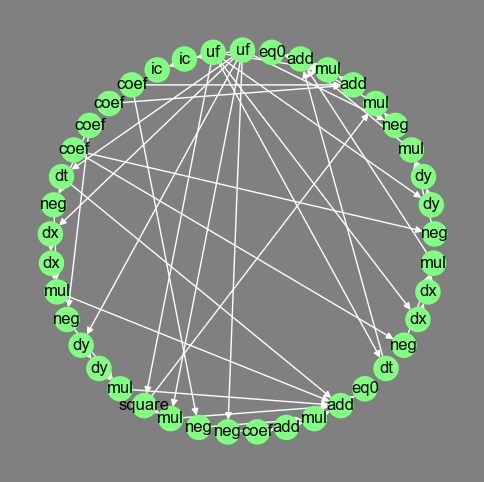

In [24]:
pde = PDENodesCollector(dim=2)
A = pde.new_uf()
B = pde.new_uf()

nx, ny = 128, 128

A_ic = reference_A[0, 0, :, :]
B_ic = reference_B[0, 0, :, :]
pde.set_ic(A, A_ic, x=xx, y=yy)
pde.set_ic(B, B_ic, x=xx, y=yy)

f = pde.new_coef(0.098)
k = pde.new_coef(0.057)
DA = pde.new_coef(2e-5)
DB = pde.new_coef(1e-5)

#dA/dt = DAΔA - AB^2 + f(1-A) -> dA/dt - DAΔA + AB^2 - f(1-A) = 0
pde.sum_eq0(A.dt,
            pde.prod(-DA, A.dx.dx),
            pde.prod(-DA, A.dy.dy),
            pde.prod(A, B.square),
            pde.prod(-f, -A+1))

#dB/dt = DBΔB + AB^2 - (f+k)B -> dB/dt - DBΔB - AB^2 + (f+k)B
pde.sum_eq0(B.dt,
            pde.prod(-DB, B.dx.dx),
            pde.prod(-DB, B.dy.dy),
            pde.prod(-A, B.square),
            pde.prod(f+k, B))

pde_dag = pde.gen_dag(config)

print(pde.node_list)
pde_dag.plot(hide='aux')

# Inference and plot

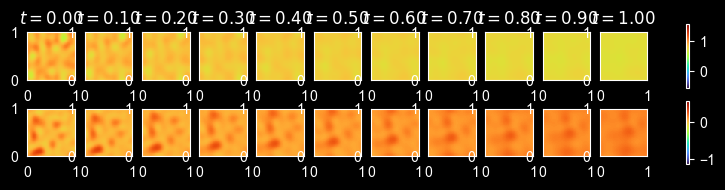

(11, 128, 128, 2)


In [25]:
snap_t = np.array([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
pred_plot = infer_plot_2d(model, pde_dag, xx, yy, snap_t=snap_t)
print(pred_plot.shape)

# Custom plotting block
This plotting block includes the pred and ground truth for both variable A (labeled as U) and variable B (labeled as V).

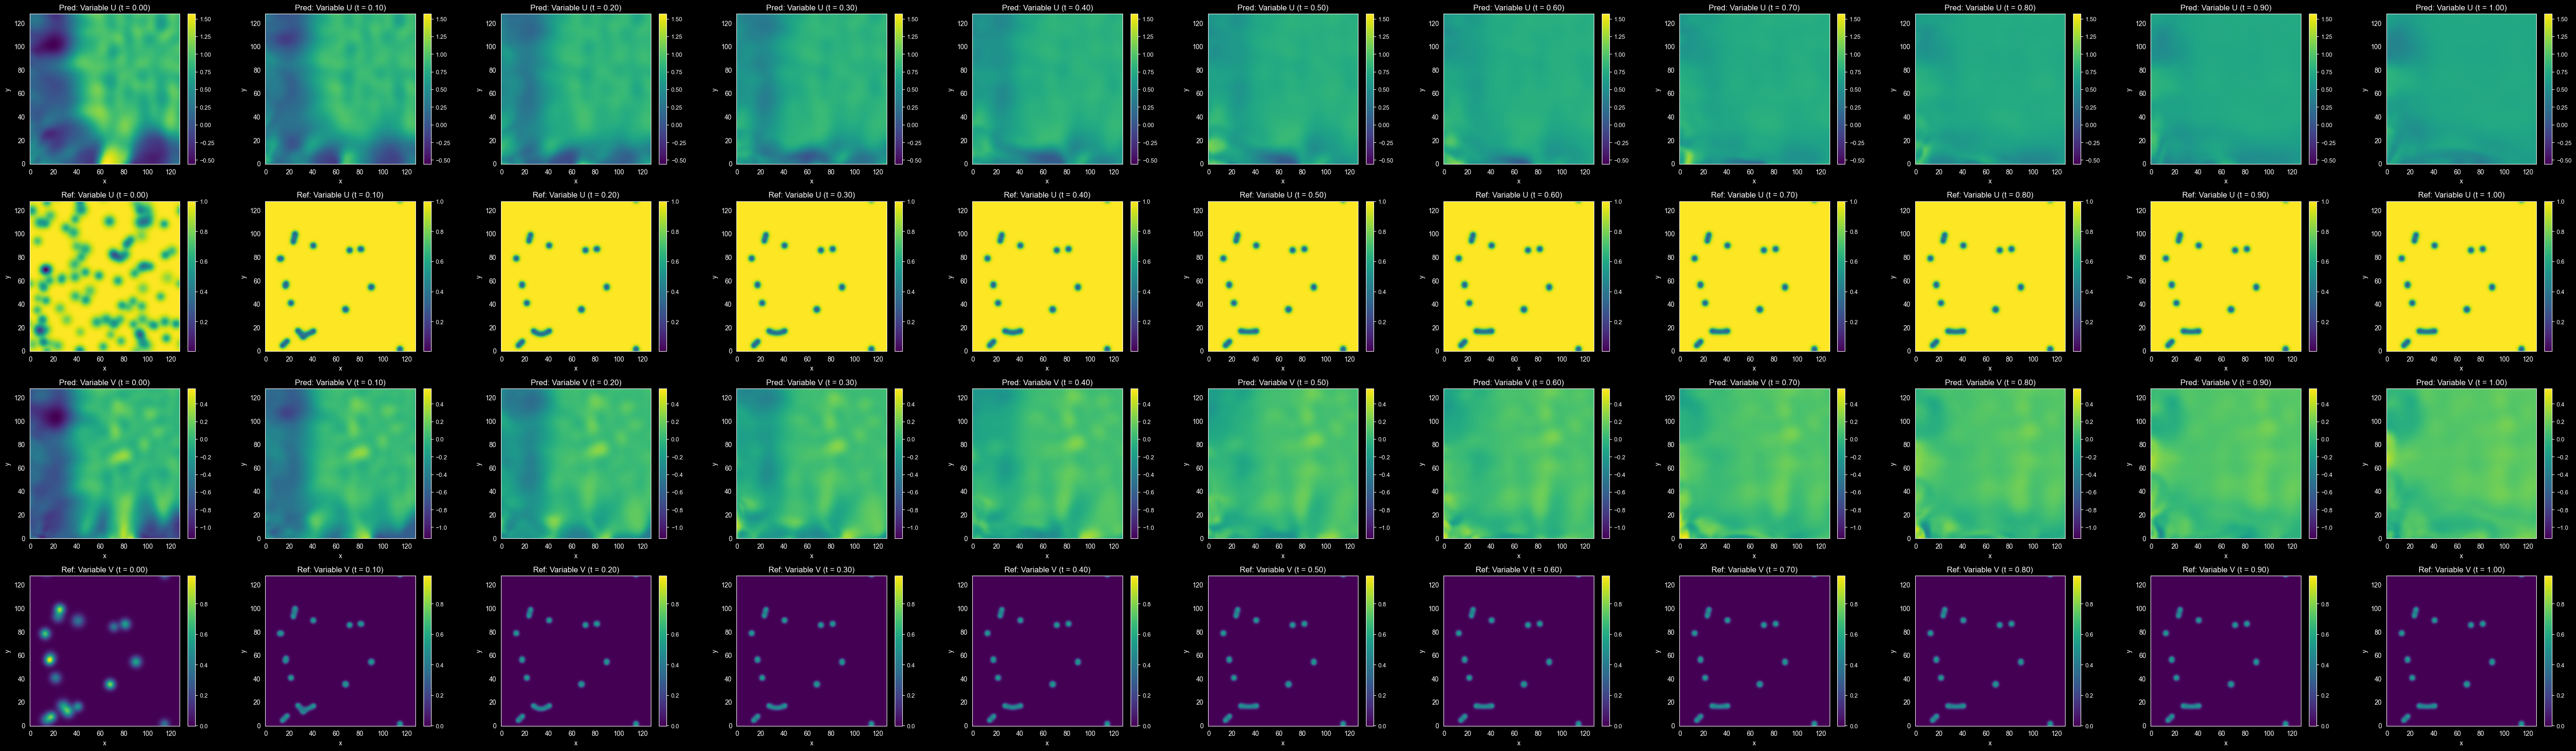

In [26]:
import matplotlib.pyplot as plt

# pred shape: (11, 128, 128, 2)
n_times = len(model_t)

# 2 Rows total (Pred U, Pred V)
fig, axes = plt.subplots(4, n_times, figsize=(5 * n_times, 16))

plot_configs = [
    {"title": "Pred: Variable U", "data": pred,      "channel": 0},
    {"title": "Ref: Variable U",  "data": reference, "channel": 0},
    {"title": "Pred: Variable V", "data": pred,      "channel": 1},
    {"title": "Ref: Variable V",  "data": reference, "channel": 1}
]

for row_idx, config in enumerate(plot_configs):

    # Calculate global min and max to lock the colorbar for this variable
    row_data = config["data"][:, :, :, config["channel"]]
    global_vmin = row_data.min()
    global_vmax = row_data.max()

    for t_idx, t in enumerate(model_t):
        ax = axes[row_idx, t_idx]

        # Extract the 128x128 grid for this specific time step
        grid_data = row_data[t_idx].T

        # Plot with locked color scales
        im = ax.imshow(grid_data, origin='lower', cmap='viridis',
                       vmin=global_vmin, vmax=global_vmax)

        # Style cleanups
        ax.grid(False)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

        ax.set_title(f"{config['title']} (t = {t:.2f})")

        # Add synchronized colorbar matching the image height
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("/Users/sky/Desktop/former2_TheWell_GSDR.pdf")
plt.show()

# IC: Random Fourier series, sim8
For visual comparison with random clusters of gaussian IC

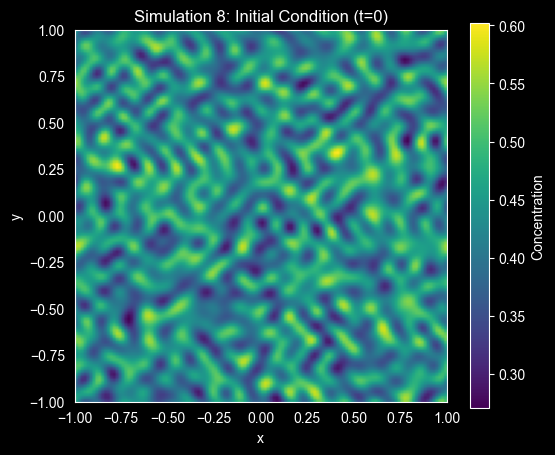

In [1]:
import h5py
import matplotlib.pyplot as plt

with h5py.File('/Volumes/T7/TheWell/datasets/gray_scott_reaction_diffusion/data/test/gray_scott_reaction_diffusion_bubbles_F_0.098_k_0.057.hdf5', 'r') as f:
    init_A = f['t0_fields']['A'][8, 0, :, :]

plt.figure(figsize=(6, 5))
plt.imshow(init_A, cmap='viridis', extent=[-1, 1, -1, 1])
plt.colorbar(label='Concentration')
plt.title('Simulation 8: Initial Condition (t=0)')
plt.grid(False)
plt.xlabel('x')
plt.ylabel('y')
plt.show()